# 9 - Copernicus GlobColour: plankton gap-fill

Runs the streaming gap-fill U-Net on the **Copernicus GlobColour** L3 multi 4km daily product
(`cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D`), reusing the PACE pipeline with two changes:

- **Land comes from the `flags` variable** (`flags == 1` is land), not derived from all-time-NaN. After
  removing land, a NaN in a variable is a real cloud or no-data gap. The explicit mask is passed into
  `build_pace_channels(..., land=...)` at every stage (stats, training tiles, inference), which matters here:
  this store covers 1997-2002, the single-sensor **swath era**, so a pixel can be a gap for a whole short
  window, and the derive-from-NaN heuristic would wrongly label it as land.
- **Multivariate head** (last section): one U-Net that gap-fills several correlated plankton groups jointly,
  so a gap in DIATO can draw on CHL and GREEN observed at the same pixel.

Part A gap-fills **CHL alone**, a minimal change from the established pipeline to confirm the dataset runs.
Part B is the joint **multivariate** model. Everything streams from a disk-backed memmap, so the full cube is
not loaded into memory at once.

Coverage note: 1997-2002 has sparse sensor coverage, so large diagonal gaps are expected. That is a harder
coverage regime than the fuller multi-sensor, post-2014 record, which is the store to pull later to test
whether the model recovers real structure rather than a smooth mean.

## Setup

In [1]:
%pip install --force-reinstall --no-cache-dir "git+https://github.com/SAFS-Varanasi-Internship/mindthegap.git@troy-branch"
!pip install -qU icechunk

  Cloning https://github.com/SAFS-Varanasi-Internship/mindthegap.git (to revision troy-branch) to /tmp/pip-req-build-2asgvnaa
  Running command git clone --filter=blob:none --quiet https://github.com/SAFS-Varanasi-Internship/mindthegap.git /tmp/pip-req-build-2asgvnaa
  Running command git checkout -b troy-branch --track origin/troy-branch
  Switched to a new branch 'troy-branch'
  branch 'troy-branch' set up to track 'origin/troy-branch'.
  Resolved https://github.com/SAFS-Varanasi-Internship/mindthegap.git to commit a283618275b3526b8f73a62badfb7c0857fc11b4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mindthegap: filename=mindthegap-0.1.0-py3-none-any.whl size=29541 sha256=7d825ccf1282027effb090666f440e0ba298790b73a1c038745e6c9077fd033a
  Stored in directory: /tmp/pip-ephem-wheel-cache-a7rnxrjf/wheels/a1/29/be/8f08433dabdc0a094cca6252bb0690294de2dc915077b47a8e
Successfully buil

In [2]:
import os
os.environ.pop("TF_CUDNN_DETERMINISTIC", None)
os.environ.pop("TF_CUDNN_USE_AUTOTUNE", None)
import icechunk as ic
import numpy as np, pandas as pd
import xarray as xr
import tensorflow as tf
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mindthegap as mtg

for _g in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_g, True)

WORKDIR = os.path.expanduser("~/shared-public/mindthegap")   # persistent storage for caches and saved models
CACHE_DIR = f"{WORKDIR}/cache"; MODEL_DIR = f"{WORKDIR}/models"
os.makedirs(CACHE_DIR, exist_ok=True); os.makedirs(MODEL_DIR, exist_ok=True)

def save_png(name, **kw):
    """Save the current figure to name, skipping the write if it fails."""
    try:
        plt.savefig(name, **kw)
    except OSError as e:
        print("savefig skipped (", e, ")")

_bpc_orig = mtg.build_pace_channels
REAL_NEIGHBORS = False   # default False keeps just the loss fix. Set True to also try feeding the model
                         # the real (unmasked) prev/next as an optional experiment.
def bpc(cc, times_w, train_w, n_days=1, cloud_mode="synthetic", coverage=0.4, blob_sigma=6.0,
        time_sigma=0.0, seed=0, stats=None, land=None, **kw):
    # build_pace_channels, then (if REAL_NEIGHBORS) overwrite prev/next with real unmasked neighbors so the
    # model gets the actual previous/next day instead of one carrying today's fake clouds.
    ch, y, st, order = _bpc_orig(cc, times_w, train_w, n_days=n_days, cloud_mode=cloud_mode,
                                 coverage=coverage, blob_sigma=blob_sigma, time_sigma=time_sigma,
                                 seed=seed, stats=stats, land=land, **kw)
    if REAL_NEIGHBORS:
        su = stats if stats is not None else st
        for k in range(1, n_days + 1):
            for nm, sh in [(f"prev{k}_CHL", k), (f"next{k}_CHL", -k)]:
                a = np.roll(cc, sh, 0)
                if sh > 0: a[:sh] = np.nan
                else: a[sh:] = np.nan
                m_, s_ = su[nm]
                ch[nm] = np.nan_to_num((a - m_) / (s_ + 1e-8), nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
    return ch, y, st, order

URL = "https://data.source.coop/fish-pace/globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"
def open_globcolour(url=URL):
    """Open the public GlobColour Icechunk store as xarray (no auth needed)."""
    storage = ic.http_storage(url)
    repo = ic.Repository.open(storage)
    containers = repo.config.virtual_chunk_containers or []
    store = ic.Repository.open(storage,
        authorize_virtual_chunk_access={p: ic.credentials.HttpAccess for p in containers}
    ).readonly_session("main").store
    return xr.open_zarr(store, consolidated=False, chunks={})

ds = open_globcolour()
CHL = "CHL"
PLANKTON = ["DIATO", "GREEN", "DINO", "HAPTO", "NANO", "PROKAR", "PICO", "MICRO", "PROCHLO"]
print("grid:", dict(ds.sizes))
print("lat:", float(ds.lat[0]), "->", float(ds.lat[-1]), "| lon:", float(ds.lon[0]), "->", float(ds.lon[-1]))
print("time:", str(ds.time.values[0])[:10], "->", str(ds.time.values[-1])[:10], "| n =", ds.sizes["time"])

2026-08-06 18:34:52.745971: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-06 18:34:52.944064: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786041292.972608    6874 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786041292.983586    6874 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786041293.162105    6874 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

grid: {'time': 8540, 'lat': 4320, 'lon': 8640}
lat: 89.97916412353516 -> -89.97917175292969 | lon: -179.9791717529297 -> 179.9791717529297
time: 1997-09-04 -> 2021-03-15 | n = 8540


## Alternative data source: recent record via Copernicus Marine

Set `USE_COPERNICUS_MARINE = True` to pull the recent multi-sensor record (post-2014, no swaths, dense PFTs)
straight from Copernicus Marine, subset to the region, instead of the source.coop 1997-2002 store. Everything
below is unchanged. One-time setup: `import copernicusmarine; copernicusmarine.login()`
(free account: https://help.marine.copernicus.eu). Left False so running all cells uses the source.coop store.

In [3]:
USE_COPERNICUS_MARINE = False    # True -> recent data from Copernicus Marine instead of the source.coop store
if USE_COPERNICUS_MARINE:
    import copernicusmarine
    ds = copernicusmarine.open_dataset(
        dataset_id="cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D",
        variables=["CHL", "flags"],                  # add DIATO, GREEN, DINO, ... for a real multivariate test
        minimum_longitude=42, maximum_longitude=80, minimum_latitude=5, maximum_latitude=31,
        start_datetime="2023-01-01", end_datetime="2024-12-31")
    ds = ds.rename({c: n for c, n in [("latitude", "lat"), ("longitude", "lon")] if c in ds.coords})
    CHL = "CHL"
    print("vars:", list(ds.data_vars), "| coords:", list(ds.coords))
    print("time:", str(ds.time.values[0])[:10], "->", str(ds.time.values[-1])[:10], "| n =", ds.sizes["time"])

## Region + land from flags

`_sel` is robust to lat/lon ordering (GlobColour is lat-descending, lon-ascending, but do not assume it).
Land is `flags == 1`, taken once (it is static) and cropped exactly like the data. `ocean = ~land`.

In [4]:
REGION = "indian_ocean"       # "arabsea" = Arabian Sea box (PACE comparison); "indian_ocean" = tropical IO, native 4 km
if REGION == "indian_ocean":
    LAT_HI, LAT_LO = 30, -30     # tropical Indian Ocean, about 1440 x 1680 at native 4 km (tiled, not coarsened)
    LON_LO, LON_HI = 40, 110
else:
    LAT_HI, LAT_LO = 31, 5       # Arabian Sea box (matches the PACE runs, for comparison)
    LON_LO, LON_HI = 42, 80

def _sel(da):
    a = da.sel(lat=slice(LAT_HI, LAT_LO))
    if a.sizes["lat"] == 0: a = da.sel(lat=slice(LAT_LO, LAT_HI))
    b = a.sel(lon=slice(LON_LO, LON_HI))
    if b.sizes["lon"] == 0: b = a.sel(lon=slice(LON_HI, LON_LO))
    return b

COMPOSITE_DAYS = 1       # 1 = daily. Set to 8 for 8-day composites: swaths rotate, so their union fills most
                         # gaps -> higher coverage + smoother target (the standard early-record product).
reg = _sel(ds[CHL])
if COMPOSITE_DAYS > 1:
    reg = reg.resample(time=f"{COMPOSITE_DAYS}D").mean()     # mean of linear chl, then logged in the cache
flg = _sel(ds["flags"].isel(time=0))
nlat, nlon = reg.sizes["lat"], reg.sizes["lon"]
cy, cx = slice(0, nlat - nlat % 8), slice(0, nlon - nlon % 8)   # crop to multiple of 8 (three 2x pools)
reg = reg.isel(lat=cy, lon=cx); flg = flg.isel(lat=cy, lon=cx)
times = reg.time.values
T, H, W = reg.sizes["time"], reg.sizes["lat"], reg.sizes["lon"]
LATV, LONV = reg.lat.values, reg.lon.values
land = (flg.values == 1); ocean = ~land
ext = [float(reg.lon.min()), float(reg.lon.max()), float(reg.lat.min()), float(reg.lat.max())]
print(f"region {H}x{W}, {T} frames ({COMPOSITE_DAYS}-day)  ->  CHL cache is about {T*H*W*4/1e9:.2f} GB")
print(f"land {land.mean():.0%}  ocean {ocean.mean():.0%}  (from flags==1)")

region 1440x1680, 8540 frames (1-day)  ->  CHL cache is about 82.64 GB
land 26%  ocean 74%  (from flags==1)


### Read speed: Source Coop icechunk vs Copernicus Marine

A read-speed check compared reading the same region and frame through both paths. The Source Coop icechunk
store was as fast or faster than the Copernicus Marine API (about 5 to 9 seconds versus 14 from this Hub), and
Copernicus Marine run in its own region in Poland reached about 6 seconds, on par with the icechunk read from
this Hub. So the icechunk store already reads at close to in-region speed, and this notebook stays on it (the
`USE_COPERNICUS_MARINE` toggle is left off). A further subset speedup is available by opening with
`chunks=None` and slicing before re-chunking, which avoids Dask overhead for a spatial subset.

In [5]:
RECENT_FRAMES = 365      # keep only the most recent N daily frames (None = whole record)
tag = f"last{RECENT_FRAMES}" if RECENT_FRAMES else "all"
CACHE = f"{CACHE_DIR}/glob_{H}x{W}_{tag}_c{COMPOSITE_DAYS}.npy"
keep = slice(max(0, T - RECENT_FRAMES), T) if RECENT_FRAMES else slice(None)
if os.path.exists(CACHE):
    mm = np.load(CACHE); times = times[keep]; T = mm.shape[0]
    print(f"reused cache -> {T} frames: {str(times[0])[:10]} -> {str(times[-1])[:10]}")
else:
    reg = reg.isel(time=keep); times = times[keep]; T = reg.sizes["time"]
    mm = np.empty((T, H, W), np.float32)
    for t0 in range(0, T, 20):
        blk = reg.isel(time=slice(t0, t0 + 20)).values
        mm[t0:t0 + 20] = np.log(np.where(blk > 0, blk, np.nan)).astype("float32")
        print("cached", min(t0 + 20, T), "/", T, flush=True)
    np.save(CACHE, mm); print(f"saved {T} frames to {CACHE}")

obs = np.mean([np.isfinite(mm[t])[ocean].mean() for t in range(0, T, max(1, T // 40))])
print(f"mean ocean coverage per frame: {obs:.0%}")

reused cache -> 365 frames: 2020-03-16 -> 2021-03-15
mean ocean coverage per frame: 60%


## Part A - CHL alone

Everything below is the established streaming pipeline (random 80/20 split, ocean-aware grid tiles, shared
global stats, whole-domain prediction). The one Copernicus change is `land=~ocean` passed into every
`build_pace_channels` call. A single feature config (`both` = time + geo) is trained; the feature ablation
itself was already run for PACE in notebook 8.

The `REGION` switch in the next cell selects the domain. `arabsea` is the Arabian Sea box used for the PACE
comparison. `indian_ocean` is the larger tropical Indian Ocean box (lat -30 to 30, lon 40 to 110) at native
4 km, about 1440 x 1680, which streams tiles the same way but uses larger 128 x 128 tiles for more spatial
context. That grid is too large to train or predict whole-domain, so prediction falls back to overlapping
tiles blended with a Hann window, following the tiling guidance in Reina et al. (2020).

In [6]:
COVERAGE = 0.2; CS = 4; N_DAYS = 3
BLOB_SIGMA = 12          # fake-cloud size in pixels (4km px -> ~48 km blobs)
LOSS_ON = "fake"         # "fake" = loss only on held-out fake-cloud pixels; "observed" = all ocean
CHUNK_H, CHUNK_W = (128, 128) if REGION == "indian_ocean" else (40, 56)   # bigger tiles = more context (Reina 2020)
MIN_OCEAN = 0.2          # keep coastal (dynamic) tiles
OVERLAP = 0
BATCH = 4 if REGION == "indian_ocean" else 16   # 128x128 tiles are ~7x the pixels, so a smaller batch fits the GPU
STEPS_PER_EPOCH = 200

rng0 = np.random.default_rng(0)
perm = rng0.permutation(T); ntr = int(0.8 * T)
tr = np.zeros(T, bool); tr[perm[:ntr]] = True; va = ~tr
train_frames = np.where(tr)[0]; val_frames = np.where(va)[0]
print("random split -> train", int(tr.sum()), "val", int(va.sum()))

step_y, step_x = CHUNK_H - OVERLAP, CHUNK_W - OVERLAP
grid_pos = [(yy, xx) for yy in range(0, H - CHUNK_H + 1, step_y)
                     for xx in range(0, W - CHUNK_W + 1, step_x)
                     if ocean[yy:yy+CHUNK_H, xx:xx+CHUNK_W].mean() >= MIN_OCEAN]
print(len(grid_pos), f"ocean tiles (MIN_OCEAN={MIN_OCEAN})")

coarse = np.asarray(mm[:, ::CS, ::CS])
_, _, STATS, ORDER = bpc(coarse, times, tr, n_days=N_DAYS, cloud_mode="synthetic",
                                             coverage=COVERAGE, blob_sigma=BLOB_SIGMA, time_sigma=1.5,
                                             seed=0, land=~ocean[::CS, ::CS])
Y_MEAN, Y_STD = STATS["CHL"]; del coarse
print("base channels:", len(ORDER), "\n", ORDER)

random split -> train 292 val 73
120 ocean tiles (MIN_OCEAN=0.2)
base channels: 13 
 ['sin_time', 'cos_time', 'masked_CHL', 'prev1_CHL', 'next1_CHL', 'prev2_CHL', 'next2_CHL', 'prev3_CHL', 'next3_CHL', 'land_flag', 'real_cloud_flag', 'valid_CHL_flag', 'fake_cloud_flag']


### Grid-tile check (colorblind-safe)

Filled dot = tile that trains, x = dropped (below `MIN_OCEAN` or in the edge strip). Grayscale background
(ocean light, land dark) so it reads without color.

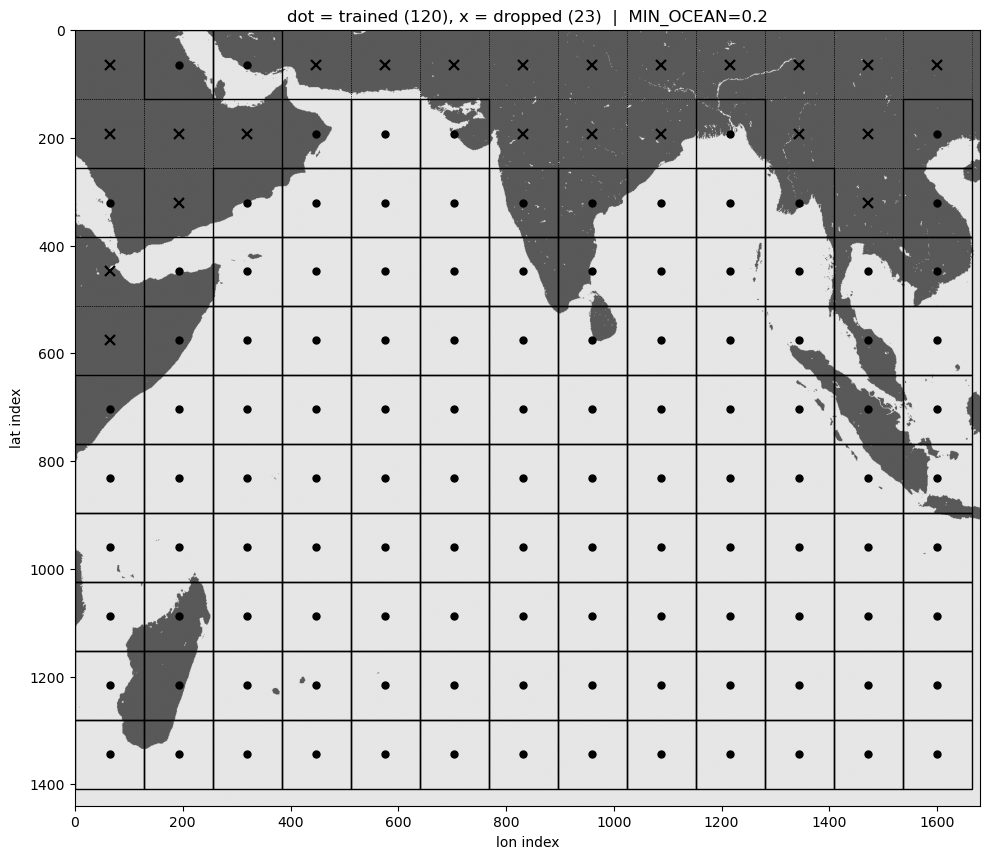

In [7]:
all_pos = [(yy, xx) for yy in range(0, H - CHUNK_H + 1, step_y)
                    for xx in range(0, W - CHUNK_W + 1, step_x)]
kept = set(grid_pos)
fig, ax = plt.subplots(figsize=(10, 9))
ax.imshow(np.where(ocean, 0.9, 0.35), cmap="gray", vmin=0, vmax=1, origin="upper")
for (yy, xx) in all_pos:
    cy_, cx_ = yy + CHUNK_H/2, xx + CHUNK_W/2
    if (yy, xx) in kept:
        ax.add_patch(mpatches.Rectangle((xx, yy), CHUNK_W, CHUNK_H, fill=False, edgecolor="black", lw=1.0))
        ax.plot(cx_, cy_, "o", ms=5, color="black")
    else:
        ax.add_patch(mpatches.Rectangle((xx, yy), CHUNK_W, CHUNK_H, fill=False, edgecolor="black", lw=0.5, ls=":"))
        ax.plot(cx_, cy_, "x", ms=7, color="black", mew=1.6)
ax.set_title(f"dot = trained ({len(kept)}), x = dropped ({len(all_pos)-len(kept)})  |  MIN_OCEAN={MIN_OCEAN}")
ax.set_xlabel("lon index"); ax.set_ylabel("lat index"); plt.tight_layout(); plt.show()

### Build channels (time + geo)

In [8]:
def keep_base():
    return list(ORDER)                       # all base channels: masked CHL, prev/next, time, flags

def geo_of(yy, xx, th, tw):
    latr = np.deg2rad(LATV[yy:yy+th])[:, None]; lonr = np.deg2rad(LONV[xx:xx+tw])[None, :]
    px = np.broadcast_to(np.cos(latr) * np.cos(lonr), (th, tw))
    py = np.broadcast_to(np.cos(latr) * np.sin(lonr), (th, tw))
    pz = np.broadcast_to(np.sin(latr), (th, tw))
    return np.stack([px, py, pz], -1).astype("float32")             # (th, tw, 3) in [-1, 1]

NC = len(keep_base()) + 3                     # + geo x/y/z
def build_XY(yy, xx, seed):
    cc = np.asarray(mm[:, yy:yy+CHUNK_H, xx:xx+CHUNK_W])
    ch, y, _, _ = bpc(cc, times, tr, n_days=N_DAYS, cloud_mode="synthetic",
                                          coverage=COVERAGE, blob_sigma=BLOB_SIGMA, time_sigma=1.5,
                                          seed=seed, stats=STATS, land=~ocean[yy:yy+CHUNK_H, xx:xx+CHUNK_W])
    Xb = np.stack([ch[k] for k in keep_base()], -1).astype("float32")
    g = geo_of(yy, xx, CHUNK_H, CHUNK_W)
    Xb = np.concatenate([Xb, np.broadcast_to(g[None], Xb.shape[:-1] + (3,))], -1).astype("float32")
    mask = ch["fake_cloud_flag"] if LOSS_ON == "fake" else np.isfinite(y).astype("float32")  # score held-out only
    return Xb, np.stack([np.nan_to_num(y, nan=0.0), mask], -1).astype("float32")
print("input channels:", NC)

input channels: 16


### Train

In [9]:
def gen():
    rng = np.random.default_rng(1)
    while True:
        tiles = list(grid_pos); rng.shuffle(tiles)
        for (yy, xx) in tiles:
            X, Y = build_XY(yy, xx, int(rng.integers(10**9)))
            fo = train_frames.copy(); rng.shuffle(fo)
            for d in fo:
                yield X[d], Y[d]

PATH = f"{MODEL_DIR}/glob_{H}x{W}_{T}_c{COMPOSITE_DAYS}_loss-{LOSS_ON}_{'realnb' if REAL_NEIGHBORS else 'masknb'}_chl.keras"
if os.path.exists(PATH):
    print("load", PATH); model = tf.keras.models.load_model(PATH, compile=False)
else:
    Xvl, Yvl = [], []
    for (yy, xx) in grid_pos[::max(1, len(grid_pos)//8)][:8]:
        X, Y = build_XY(yy, xx, 7); Xvl.append(X[val_frames]); Yvl.append(Y[val_frames])
    Xva = np.concatenate(Xvl).astype("float32"); Yva = np.concatenate(Yvl).astype("float32")
    sig = (tf.TensorSpec((CHUNK_H, CHUNK_W, NC), tf.float32), tf.TensorSpec((CHUNK_H, CHUNK_W, 2), tf.float32))
    ds_tr = (tf.data.Dataset.from_generator(gen, output_signature=sig)
             .shuffle(512 if REGION == "indian_ocean" else 2048).batch(BATCH, drop_remainder=True).prefetch(2))
    model = mtg.UNet((None, None, NC)); model.compile("adam", loss=mtg.masked_mse, jit_compile=False)
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
    model.fit(ds_tr, steps_per_epoch=STEPS_PER_EPOCH, validation_data=(Xva, Yva),
              epochs=40, callbacks=[es], verbose=2)
    os.makedirs(MODEL_DIR, exist_ok=True); model.save(PATH); del Xva, Yva
print("ready")

Epoch 1/40
200/200 - 33s - 164ms/step - loss: 0.1723 - mae: 0.7285 - val_loss: 0.4407 - val_mae: 0.7953
Epoch 2/40
200/200 - 15s - 77ms/step - loss: 0.2453 - mae: 0.9992 - val_loss: 0.8608 - val_mae: 1.0733
Epoch 3/40
200/200 - 12s - 62ms/step - loss: 0.2208 - mae: 1.4923 - val_loss: 0.3491 - val_mae: 1.4190
Epoch 4/40
200/200 - 15s - 74ms/step - loss: 0.0891 - mae: 0.6501 - val_loss: 0.5984 - val_mae: 1.6966
Epoch 5/40
200/200 - 15s - 76ms/step - loss: 0.2146 - mae: 1.1077 - val_loss: 1.5973 - val_mae: 2.1094
Epoch 6/40
200/200 - 15s - 75ms/step - loss: 0.5422 - mae: 2.2503 - val_loss: 0.2457 - val_mae: 1.5271
Epoch 7/40
200/200 - 12s - 62ms/step - loss: 0.3762 - mae: 1.3057 - val_loss: 0.3015 - val_mae: 1.5413
Epoch 8/40
200/200 - 15s - 74ms/step - loss: 0.3398 - mae: 2.4029 - val_loss: 0.2142 - val_mae: 1.5810
Epoch 9/40
200/200 - 15s - 74ms/step - loss: 0.3356 - mae: 2.7593 - val_loss: 0.2286 - val_mae: 1.3964
Epoch 10/40
200/200 - 15s - 74ms/step - loss: 0.1654 - mae: 1.5139 - val

### Compare vs persistence (held-out fake clouds)

Whole-domain prediction in one pass, with a Hann-window tiled fallback used only if a single pass does not
fit in memory. Coast vs open split, scored against standard persistence (yesterday's real observed pixel).

primary, all held-out pixels:
  U-Net             coast 0.5670   open 0.2490   all 0.2652
  nearest-neighbor                               all 0.1160
secondary (temporal): persistence 0.1266, but only on 20% of held-out pixels


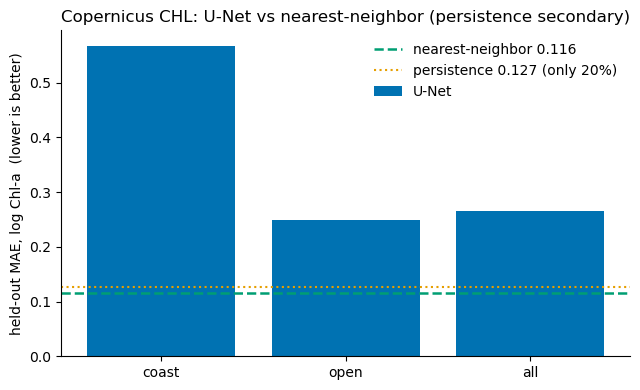

In [10]:
PRED_TH = max(8, (H // 3 // 8) * 8); PRED_TW = max(8, (W // 3 // 8) * 8)
def _predict(model, X):
    try:
        return model.predict(X[None], verbose=0)[0, ..., 0] * Y_STD + Y_MEAN
    except tf.errors.ResourceExhaustedError:
        Hh, Ww, _ = X.shape; th = (min(Hh, PRED_TH)//8)*8; tw = (min(Ww, PRED_TW)//8)*8
        sh, sw = th//2, tw//2; wgt = np.outer(np.hanning(th), np.hanning(tw)) + 1e-3
        acc = np.zeros((Hh, Ww), np.float32); cnt = np.zeros((Hh, Ww), np.float32)
        yl = list(range(0, Hh-th+1, sh)) or [0]; xl = list(range(0, Ww-tw+1, sw)) or [0]
        if yl[-1] != Hh-th: yl.append(Hh-th)
        if xl[-1] != Ww-tw: xl.append(Ww-tw)
        for a in yl:
            for b in xl:
                p = model.predict(X[a:a+th, b:b+tw][None], verbose=0)[0, :, :, 0]
                acc[a:a+th, b:b+tw] += p*wgt; cnt[a:a+th, b:b+tw] += wgt
        return acc/np.maximum(cnt, 1e-6) * Y_STD + Y_MEAN

geo_full = geo_of(0, 0, H, W)
def predict_day(model, d):
    lo = max(0, d-N_DAYS); hi = min(T, d+N_DAYS+1); mid = int(d-lo)
    win = np.asarray(mm[lo:hi])
    ch, y, _, _ = bpc(win, times[lo:hi], np.ones(win.shape[0], bool),
                                          n_days=N_DAYS, coverage=COVERAGE, blob_sigma=BLOB_SIGMA,
                                          time_sigma=1.5, seed=1000+int(d), stats=STATS, land=~ocean)
    faked = ch["fake_cloud_flag"][mid].astype(bool); truth = win[mid]
    fake_prev = ch["fake_cloud_flag"][mid-1].astype(bool) if mid >= 1 else np.zeros_like(faked)  # yesterday's fake clouds
    Xd = np.concatenate([np.stack([ch[k] for k in keep_base()], -1)[mid], geo_full], -1)
    return truth, faked, _predict(model, Xd.astype("float32")), fake_prev

coast = ocean & (ndimage.distance_transform_edt(ocean) <= 8)
openoc = ocean & ~coast
SCORE = val_frames[(val_frames >= 3) & (val_frames < T - 3)][:16]

def mae_on(pred, truth, mask):
    m = mask & np.isfinite(truth) & np.isfinite(pred)
    return float(np.mean(np.abs(pred[m] - truth[m]))) if m.any() else np.nan

# Primary baseline is nearest-neighbor, a real spatial gap-fill: it fills every held-out pixel from the
# un-hidden pixels of the same frame, the same task and the same masked data the model works from. So the
# U-Net and nearest-neighbor are scored on ALL held-out pixels. Persistence is only a secondary temporal
# check: it can predict solely where yesterday survives the fake clouds, so it is scored on that small subset
# and reported with its coverage.
def nn_fill(truth, observed):
    if not observed.any(): return np.full_like(truth, np.nan)
    _, (iy, ix) = ndimage.distance_transform_edt(~observed, return_indices=True)
    return np.where(observed, truth, np.nan)[iy, ix]

rows = {k: [] for k in ["m_coast", "m_open", "m_all", "nn_all", "p_sub", "cov"]}
for d in SCORE:
    truth, faked, filled, fake_prev = predict_day(model, d)
    held = faked & ocean & np.isfinite(truth)                        # all held-out pixels = the actual task
    nn = nn_fill(truth, ocean & ~faked & np.isfinite(truth))         # trivial spatial fill from un-hidden pixels
    prev = np.where(fake_prev, np.nan, np.asarray(mm[d - 1])); haveprev = np.isfinite(prev)
    rows["m_coast"].append(mae_on(filled, truth, held & coast))
    rows["m_open"].append(mae_on(filled, truth, held & openoc))
    rows["m_all"].append(mae_on(filled, truth, held))
    rows["nn_all"].append(mae_on(nn, truth, held))                   # nearest-neighbor on the SAME held-out pixels
    rows["p_sub"].append(mae_on(prev, truth, held & haveprev))       # persistence only where yesterday survives
    rows["cov"].append(float((held & haveprev).sum() / max(1, held.sum())))
res = {k: float(np.nanmean(v)) for k, v in rows.items()}
print("primary, all held-out pixels:")
print(f"  U-Net             coast {res['m_coast']:.4f}   open {res['m_open']:.4f}   all {res['m_all']:.4f}")
print(f"  nearest-neighbor                               all {res['nn_all']:.4f}")
print(f"secondary (temporal): persistence {res['p_sub']:.4f}, but only on {res['cov']:.0%} of held-out pixels")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(["coast", "open", "all"], [res["m_coast"], res["m_open"], res["m_all"]], color="#0072B2", label="U-Net")
ax.axhline(res["nn_all"], ls="--", color="#009E73", lw=1.8, label=f"nearest-neighbor {res['nn_all']:.3f}")
ax.axhline(res["p_sub"], ls=":", color="#E69F00", lw=1.5, label=f"persistence {res['p_sub']:.3f} (only {res['cov']:.0%})")
ax.set_ylabel("held-out MAE, log Chl-a  (lower is better)"); ax.legend(frameon=False)
ax.set_title("Copernicus CHL: U-Net vs nearest-neighbor (persistence secondary)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); save_png("copernicus_chl_compare.png", dpi=140, bbox_inches="tight"); plt.show()

### Check: persistence vs model on train and val (per-pixel)

Diagnostic check. If persistence beats the model on the data it trained on, the model is not learning to use
the yesterday feature, which points to the loss being scored on the wrong pixels. With `LOSS_ON="fake"` the
model should win or tie on train.

In [11]:
for _name, _frames in [("train", train_frames), ("val", val_frames)]:
    _fr = _frames[(_frames >= N_DAYS) & (_frames < T - N_DAYS)]
    _r = {"m": [], "p": []}
    for _d in _fr:
        _t, _f, _fl, _fp = predict_day(model, int(_d))
        _pv = np.where(_fp, np.nan, np.asarray(mm[_d - 1])); _m = _f & ocean & np.isfinite(_pv) & np.isfinite(_t)
        _r["m"].extend(np.abs(_fl[_m] - _t[_m])); _r["p"].extend(np.abs(_pv[_m] - _t[_m]))
    print(f"{_name:>5}: U-Net {np.mean(_r['m']):.4f}  persist {np.mean(_r['p']):.4f}  n={len(_r['m'])}")

train: U-Net 0.2318  persist 0.1362  n=9815310
  val: U-Net 0.2333  persist 0.1340  n=2473487


### A few days: input, fill, truth, error

Shared color scale. Along the swaths, the fill should be a smooth, position-appropriate field rather than a
single flat value.

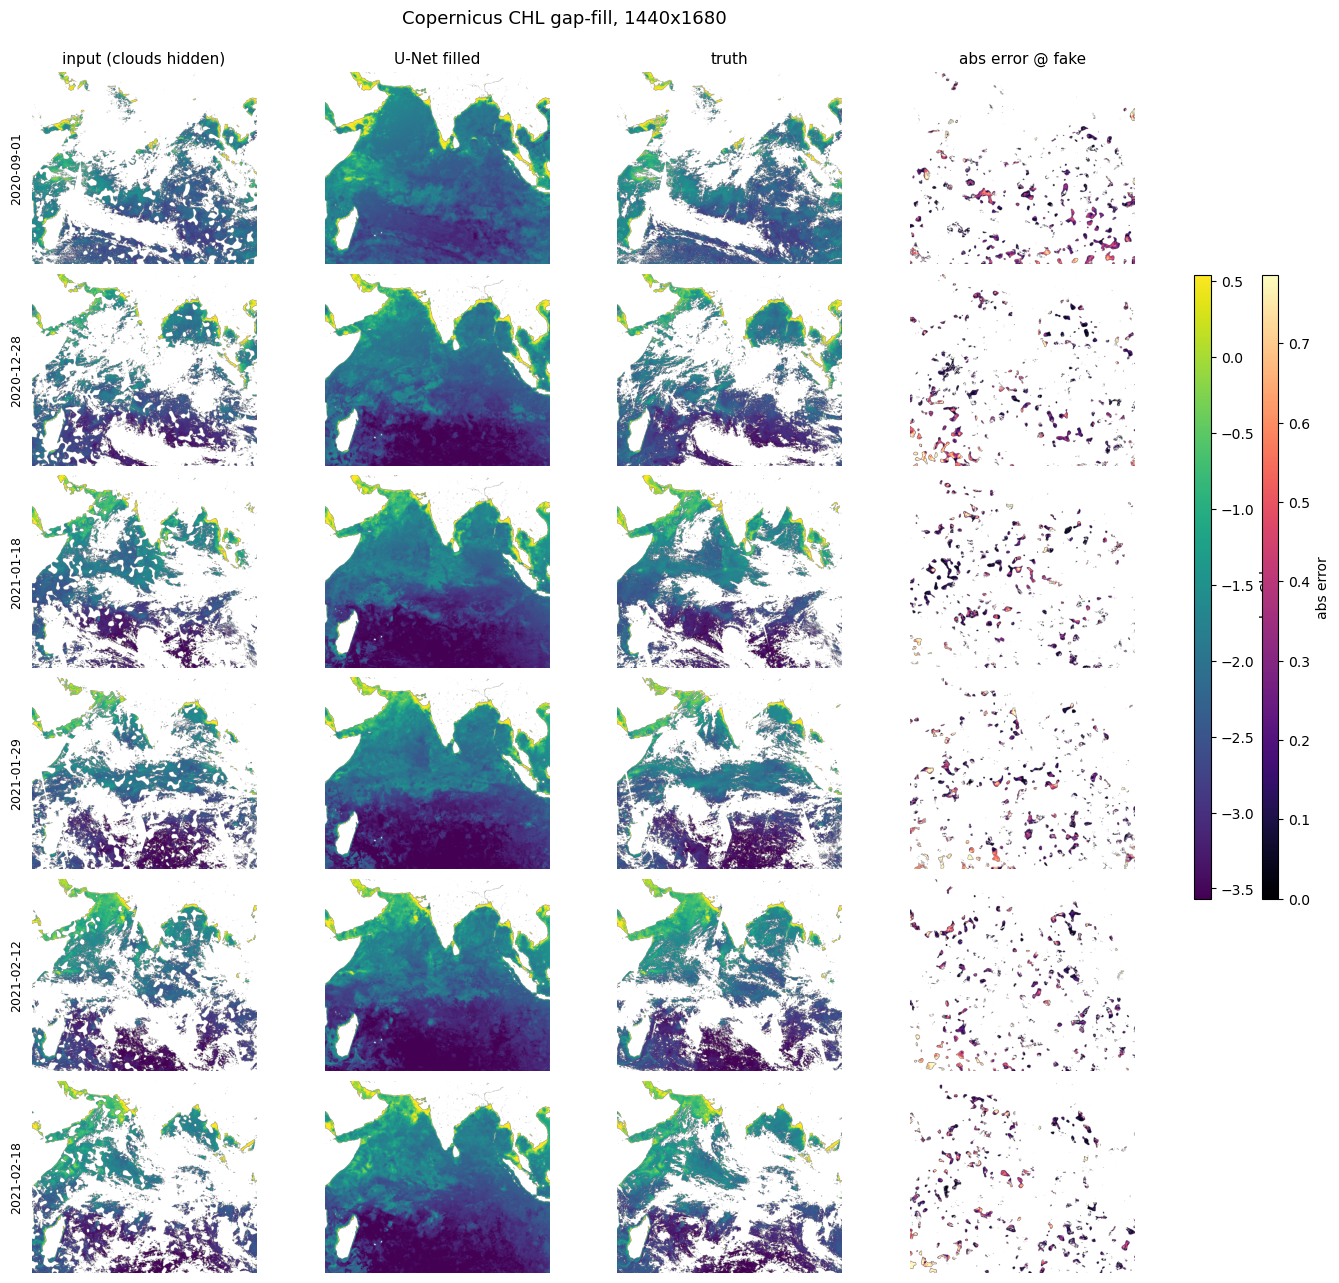

: 

In [ ]:
elig = val_frames[(val_frames >= 3) & (val_frames < T - 3)]
obsf = np.array([np.isfinite(mm[d])[ocean].mean() for d in elig])
pick = elig[np.argsort(np.abs(obsf - 0.5))][:6]          # moderate-gap days, some context to fill from
pick = np.sort(pick)
store = {int(d): predict_day(model, int(d)) for d in pick}
flat = np.concatenate([np.asarray(mm[d])[ocean] for d in pick])
vmin, vmax = np.nanpercentile(flat[np.isfinite(flat)], [2, 98])
allerr = np.concatenate([np.abs(store[int(d)][2] - store[int(d)][0])[store[int(d)][1]] for d in pick])
emax = float(np.nanpercentile(allerr[np.isfinite(allerr)], 95))

tt = ["input (clouds hidden)", "U-Net filled", "truth", "abs error @ fake"]
fig, axes = plt.subplots(len(pick), 4, figsize=(15, 2.6 * len(pick)))
for i, d in enumerate(pick):
    truth, faked, filled, _ = store[int(d)]; holes = faked | ~np.isfinite(truth)
    arrs = [np.where(holes, np.nan, truth), np.where(ocean, filled, np.nan),
            np.where(ocean, truth, np.nan), np.where(faked, np.abs(filled - truth), np.nan)]
    for j, arr in enumerate(arrs):
        ax = axes[i, j]; cm, l, h = ("magma", 0, emax) if j == 3 else ("viridis", vmin, vmax)
        ax.imshow(arr, cmap=cm, vmin=l, vmax=h, extent=ext, origin="upper"); ax.axis("off")
        if i == 0: ax.set_title(tt[j], size=11)
    axes[i, 0].text(-0.04, 0.5, str(pd.to_datetime(times[d]).date()), transform=axes[i, 0].transAxes,
                    rotation=90, va="center", ha="right", size=9)
fig.subplots_adjust(right=0.9, hspace=0.05, wspace=0.03)
c1 = fig.add_axes([0.92, 0.35, 0.011, 0.4]); fig.colorbar(
    plt.cm.ScalarMappable(plt.Normalize(vmin, vmax), "viridis"), cax=c1, label="log Chl-a")
c2 = fig.add_axes([0.965, 0.35, 0.011, 0.4]); fig.colorbar(
    plt.cm.ScalarMappable(plt.Normalize(0, emax), "magma"), cax=c2, label="abs error")
plt.suptitle(f"Copernicus CHL gap-fill, {H}x{W}", y=0.92, size=13)
save_png("copernicus_chl_days.png", dpi=120, bbox_inches="tight"); plt.show()

## Cloud-size ablation: U-Net vs persistence vs nearest-neighbor

Trains one model per synthetic cloud size (matched train/eval, using the `LOSS_ON` loss) and scores each
against standard persistence and a trivial nearest-neighbor fill (each hidden pixel copies its closest
observed pixel). Persistence is a temporal predictor, so it is roughly flat across sizes; nearest-neighbor is
cheap but strong for small gaps and degrades as gaps grow; the U-Net has to beat both to earn its place.
Resumable: models are saved per size and skipped if already present (keyed by size and loss), so a re-run
loads the finished sizes from disk.

In [13]:
from scipy.ndimage import distance_transform_edt
SIZES = [4, 8, 12, 20]
def _nn_fill(truth, observed):
    if not observed.any(): return np.full_like(truth, np.nan)
    _, (iy, ix) = distance_transform_edt(~observed, return_indices=True)
    return np.where(observed, truth, np.nan)[iy, ix]

score_frames = val_frames[(val_frames >= N_DAYS) & (val_frames < T - N_DAYS)]
sweep = {}
for bs in SIZES:
    cc = np.asarray(mm[:, ::CS, ::CS])
    _, _, ST, _ = bpc(cc, times, tr, n_days=N_DAYS, cloud_mode="synthetic",
                    coverage=COVERAGE, blob_sigma=bs, time_sigma=1.5, seed=0, land=~ocean[::CS, ::CS]); del cc
    def bx(yy, xx, seed, ST=ST, bs=bs):
        c2 = np.asarray(mm[:, yy:yy+CHUNK_H, xx:xx+CHUNK_W])
        ch, y, _, _ = bpc(c2, times, tr, n_days=N_DAYS, cloud_mode="synthetic",
                        coverage=COVERAGE, blob_sigma=bs, time_sigma=1.5, seed=seed, stats=ST,
                        land=~ocean[yy:yy+CHUNK_H, xx:xx+CHUNK_W])
        Xb = np.stack([ch[k] for k in keep_base()], -1).astype("float32")
        g = geo_of(yy, xx, CHUNK_H, CHUNK_W)
        Xb = np.concatenate([Xb, np.broadcast_to(g[None], Xb.shape[:-1]+(3,))], -1).astype("float32")
        mask = ch["fake_cloud_flag"] if LOSS_ON == "fake" else np.isfinite(y).astype("float32")
        return Xb, np.stack([np.nan_to_num(y, nan=0.0), mask], -1).astype("float32")
    NCb = len(keep_base()) + 3
    path = f"{MODEL_DIR}/glob_{H}x{W}_{T}_c{COMPOSITE_DAYS}_bs{bs}_loss-{LOSS_ON}_{'realnb' if REAL_NEIGHBORS else 'masknb'}_chl.keras"
    if os.path.exists(path):
        mdl = tf.keras.models.load_model(path, compile=False); print(f"loaded bs={bs}", flush=True)
    else:
        def gen(ST=ST, bs=bs):
            rng = np.random.default_rng(1)
            while True:
                tiles = list(grid_pos); rng.shuffle(tiles)
                for (yy, xx) in tiles:
                    X, Y = bx(yy, xx, int(rng.integers(10**9)))
                    fo = train_frames.copy(); rng.shuffle(fo)
                    for d in fo: yield X[d], Y[d]
        Xvl, Yvl = [], []
        for (yy, xx) in grid_pos[::max(1, len(grid_pos)//8)][:8]:
            X, Y = bx(yy, xx, 7); Xvl.append(X[val_frames]); Yvl.append(Y[val_frames])
        Xva = np.concatenate(Xvl).astype("float32"); Yva = np.concatenate(Yvl).astype("float32")
        sig = (tf.TensorSpec((CHUNK_H, CHUNK_W, NCb), tf.float32), tf.TensorSpec((CHUNK_H, CHUNK_W, 2), tf.float32))
        dtr = (tf.data.Dataset.from_generator(gen, output_signature=sig)
               .shuffle(2048).batch(BATCH, drop_remainder=True).prefetch(2))
        mdl = mtg.UNet((None, None, NCb)); mdl.compile("adam", loss=mtg.masked_mse, jit_compile=False)
        es = tf.keras.callbacks.EarlyStopping("val_loss", patience=6, restore_best_weights=True)
        print(f"training blob_sigma={bs} (loss={LOSS_ON})...", flush=True)
        mdl.fit(dtr, steps_per_epoch=STEPS_PER_EPOCH, validation_data=(Xva, Yva), epochs=40, callbacks=[es], verbose=2)
        os.makedirs(MODEL_DIR, exist_ok=True); mdl.save(path); del Xva, Yva
    r = {"unet": [], "pers": [], "nn": []}
    for d in score_frames:
        lo = max(0, d-N_DAYS); hi = min(T, d+N_DAYS+1); mid = int(d-lo); win = np.asarray(mm[lo:hi])
        ch, _, _, _ = bpc(win, times[lo:hi], np.ones(win.shape[0], bool), n_days=N_DAYS,
                        cloud_mode="synthetic", coverage=COVERAGE, blob_sigma=bs, time_sigma=1.5,
                        seed=1000+int(d), stats=ST, land=~ocean)
        faked = ch["fake_cloud_flag"][mid].astype(bool); truth = win[mid]
        fake_prev = ch["fake_cloud_flag"][mid-1].astype(bool) if mid >= 1 else np.zeros_like(faked)
        prev = np.where(fake_prev, np.nan, np.asarray(mm[d-1]))   # persistence sees the same fake clouds as the model
        Xd = np.concatenate([np.stack([ch[k] for k in keep_base()], -1)[mid], geo_full], -1).astype("float32")
        filled = _predict(mdl, Xd); nn = _nn_fill(truth, ocean & ~faked & np.isfinite(truth))
        held = faked & ocean & np.isfinite(truth)                    # U-Net and nearest-neighbor: all held-out pixels
        hp = held & np.isfinite(prev)                                # persistence: only where yesterday survives
        r["unet"].extend(np.abs(filled[held]-truth[held])); r["nn"].extend(np.abs(nn[held]-truth[held]))
        r["pers"].extend(np.abs(prev[hp]-truth[hp]))
    sweep[bs] = {k: float(np.mean(v)) for k, v in r.items()}
    print(f"bs={bs}: U-Net {sweep[bs]['unet']:.4f}  persist {sweep[bs]['pers']:.4f}  nearest {sweep[bs]['nn']:.4f}", flush=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(SIZES, [sweep[s]["unet"] for s in SIZES], "o-",  color="#0072B2", label="U-Net")
ax.plot(SIZES, [sweep[s]["pers"] for s in SIZES], "s--", color="#E69F00", label="persistence")
ax.plot(SIZES, [sweep[s]["nn"]   for s in SIZES], "^-",  color="#009E73", label="nearest-neighbor")
ax.set_xlabel("synthetic cloud size (blob_sigma, px)"); ax.set_ylabel("held-out MAE, log Chl-a (pooled)")
ax.set_title(f"Gap-fill vs gap size (loss={LOSS_ON})"); ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); save_png("cloud_size_sweep.png", dpi=140, bbox_inches="tight"); plt.show()

: 

: 

## Part B - Multivariate (joint plankton groups)

The plankton groups are correlated, and a cloud hides all of them at once, so they are gap-filled **jointly**:
one U-Net with `V` input blocks (masked value plus prev/next per variable) plus shared time, geo, and land,
and `V` output channels. The loss scores each variable only at its own observed-and-hidden pixels. The
benefit is that DIATO's fill at a pixel can use CHL and GREEN observed at that same pixel.

The region is held **in memory**, not in a disk cache: a 9-day composite of one basin is only ~0.5 GB per
variable, so there is no need to write it to disk. Tiles still stream to the model exactly as before; only the
local copy the stream reads from moves from a disk memmap to memory. CHL is reused from its Part A disk cache,
so only the extra variables download. `VARS` starts at two; add the rest from `PLANKTON` to scale up. The
in-memory copy is rebuilt when the session restarts. Set `RUN_MV=True` to build.

In [ ]:
RUN_MV = True
VARS = ["CHL", "DIATO"]          # start small; add GREEN, DINO, HAPTO, NANO, PROKAR, PICO, MICRO, PROCHLO
V = len(VARS)
print(f"{V} variables x {T*H*W*4/1e9:.2f} GB = about {V*T*H*W*4/1e9:.2f} GB in memory")

In [ ]:
if RUN_MV:
    # Hold the composite region in memory (V x ~0.5 GB) and stream tiles from it, identical to the disk path
    # but with no cache file. CHL is reused from its Part A disk cache, so only the extra variables download.
    # The in-memory copy is rebuilt when the session restarts.
    mmv = np.empty((V, T, H, W), np.float32)
    for vi, vn in enumerate(VARS):
        if vn == CHL:
            mmv[vi] = mm[:]; print(f"reused {vn} from {CACHE}", flush=True); continue
        rv = _sel(ds[vn])
        if COMPOSITE_DAYS > 1: rv = rv.resample(time=f"{COMPOSITE_DAYS}D").mean()
        rv = rv.isel(lat=cy, lon=cx, time=slice(-T, None))    # crop and take the recent window (matches CHL)
        for t0 in range(0, T, 20):
            blk = rv.isel(time=slice(t0, t0 + 20)).values
            mmv[vi, t0:t0 + 20] = np.log(np.where(blk > 0, blk, np.nan)).astype("float32")
            print(f"  {vn}: {min(t0+20, T)}/{T}", flush=True)     # per-block progress
        print("downloaded", vn, flush=True)

    # per-variable shared/global stats (same coarse read as CHL) + true coverage
    STATS_V, Y_MS = [], []
    for vi in range(V):
        cv = np.asarray(mmv[vi, :, ::CS, ::CS])
        _, _, sv, _ = bpc(cv, times, tr, n_days=N_DAYS, cloud_mode="synthetic",
                                              coverage=COVERAGE, blob_sigma=BLOB_SIGMA, time_sigma=1.5,
                                              seed=0, land=~ocean[::CS, ::CS])
        STATS_V.append(sv); Y_MS.append(sv["CHL"]); del cv
    for vi, vn in enumerate(VARS):
        a = mmv[vi, ::4][:, ocean]; fin = np.isfinite(a)
        print(f"{vn:>8}: coverage {fin.mean():.2%}  log-std {a[fin].std():.3f}")

In [ ]:
# per variable: masked value, its observed-mask (so the model knows what is missing), prev/next
VKEYS = (["masked_CHL", "valid_CHL_flag"]
         + [f"prev{k}_CHL" for k in range(1, N_DAYS+1)] + [f"next{k}_CHL" for k in range(1, N_DAYS+1)])
PER_VAR = len(VKEYS)                              # channels contributed by each variable
NC_MV = V * PER_VAR + 3 + 3                       # + shared sin/cos/land + geo x/y/z

def build_XY_mv(yy, xx, seed):
    sl = (slice(None), slice(yy, yy+CHUNK_H), slice(xx, xx+CHUNK_W))
    lnd = ~ocean[yy:yy+CHUNK_H, xx:xx+CHUNK_W]
    xs, vals, masks, ch = [], [], [], None
    for vi in range(V):
        cc = np.asarray(mmv[vi][sl])
        ch, y, _, _ = bpc(cc, times, tr, n_days=N_DAYS, cloud_mode="synthetic",
                                              coverage=COVERAGE, blob_sigma=BLOB_SIGMA, time_sigma=1.5,
                                              seed=seed, stats=STATS_V[vi], land=lnd)   # same seed -> same cloud geometry
        xs.append(np.stack([ch[k] for k in VKEYS], -1).astype("float32"))
        tm = mtg.target_with_mask(y); vals.append(tm[..., 0:1]); masks.append(tm[..., 1:2])
    g = geo_of(yy, xx, CHUNK_H, CHUNK_W)
    shared = np.stack([ch["sin_time"], ch["cos_time"], ch["land_flag"]], -1).astype("float32")
    gb = np.broadcast_to(g[None], (T, CHUNK_H, CHUNK_W, 3))
    X = np.concatenate(xs + [shared, gb], -1).astype("float32")            # (T, th, tw, NC_MV)
    Y = np.concatenate(vals + masks, -1).astype("float32")                 # (T, th, tw, 2V): V values then V masks
    return X, Y

def make_mv_loss(V):
    def loss(y_true, y_pred):
        yt = y_true[..., :V]; mk = y_true[..., V:]
        return tf.reduce_sum(tf.square(yt - y_pred) * mk) / (tf.reduce_sum(mk) + 1e-6)
    return loss

def UNetK(input_shape, out_ch):
    from tensorflow.keras import Input, layers
    inp = Input(shape=input_shape); x = inp; filters = [64, 128, 256]; ec = []
    for f in filters:
        ec.append(x)
        x = layers.Conv2D(f, (3, 3), padding="same", activation="relu")(x)
        x = layers.Conv2D(f, (3, 3), padding="same", activation="relu")(x)
        x = layers.MaxPooling2D()(x); x = layers.BatchNormalization()(x)
    for f, e in zip(filters[:-1][::-1], ec[::-1][:-1]):
        x = layers.Conv2DTranspose(f, 3, 2, padding="same")(x)
        x = layers.concatenate([x, e])
        x = layers.Conv2D(f, (3, 3), padding="same", activation="relu")(x)
        x = layers.Conv2D(f, (3, 3), padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(f, 3, 2, padding="same")(x)
    x = layers.concatenate([x, ec[0]])
    x = layers.Conv2D(f, (3, 3), padding="same", activation="relu")(x)
    out = layers.Conv2D(out_ch, (3, 3), padding="same", activation="linear")(x)
    return tf.keras.Model(inp, out, name="U-net-mv")

if RUN_MV: print("multivariate input channels:", NC_MV, "| output channels:", V)

In [ ]:
def gen_mv():
    rng = np.random.default_rng(1)
    while True:
        tiles = list(grid_pos); rng.shuffle(tiles)
        for (yy, xx) in tiles:
            X, Y = build_XY_mv(yy, xx, int(rng.integers(10**9)))
            fo = train_frames.copy(); rng.shuffle(fo)
            for d in fo:
                yield X[d], Y[d]

if RUN_MV:
    PATH_MV = f"{MODEL_DIR}/mv_{H}x{W}_{T}_c{COMPOSITE_DAYS}_{'-'.join(VARS)}.keras"
    if os.path.exists(PATH_MV):
        print("load", PATH_MV); model_mv = tf.keras.models.load_model(PATH_MV, compile=False)
    else:
        Xvl, Yvl = [], []
        for (yy, xx) in grid_pos[::max(1, len(grid_pos)//6)][:6]:
            X, Y = build_XY_mv(yy, xx, 7); Xvl.append(X[val_frames]); Yvl.append(Y[val_frames])
        Xva = np.concatenate(Xvl).astype("float32"); Yva = np.concatenate(Yvl).astype("float32")
        sig = (tf.TensorSpec((CHUNK_H, CHUNK_W, NC_MV), tf.float32), tf.TensorSpec((CHUNK_H, CHUNK_W, 2*V), tf.float32))
        ds_tr = (tf.data.Dataset.from_generator(gen_mv, output_signature=sig)
                 .shuffle(1024).batch(BATCH, drop_remainder=True).prefetch(2))
        model_mv = UNetK((None, None, NC_MV), V)
        model_mv.compile("adam", loss=make_mv_loss(V), jit_compile=False)
        es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
        model_mv.fit(ds_tr, steps_per_epoch=STEPS_PER_EPOCH, validation_data=(Xva, Yva),
                     epochs=40, callbacks=[es], verbose=2)
        model_mv.save(PATH_MV); del Xva, Yva
    print("multivariate model ready")

### Multivariate: per-variable MAE vs persistence

Same held-out fake clouds, scored per variable. Whole-domain prediction runs on CPU for the scoring frames,
which are only a handful, so the `V` output channels fit comfortably.

In [ ]:
def _predict_mv(model, X):
    try:
        return model.predict(X[None], verbose=0)[0]                       # (H, W, V) whole domain, on GPU
    except tf.errors.ResourceExhaustedError:                              # tile and feather only if a single pass does not fit
        Hh, Ww, _ = X.shape; th = (min(Hh, PRED_TH)//8)*8; tw = (min(Ww, PRED_TW)//8)*8
        sh, sw = th//2, tw//2; wgt = (np.outer(np.hanning(th), np.hanning(tw)) + 1e-3)[..., None]
        acc = np.zeros((Hh, Ww, V), np.float32); cnt = np.zeros((Hh, Ww, 1), np.float32)
        yl = list(range(0, Hh-th+1, sh)) or [0]; xl = list(range(0, Ww-tw+1, sw)) or [0]
        if yl[-1] != Hh-th: yl.append(Hh-th)
        if xl[-1] != Ww-tw: xl.append(Ww-tw)
        for a in yl:
            for b in xl:
                acc[a:a+th, b:b+tw] += model.predict(X[a:a+th, b:b+tw][None], verbose=0)[0]*wgt
                cnt[a:a+th, b:b+tw] += wgt
        return acc/np.maximum(cnt, 1e-6)

def predict_day_mv(model, d):
    lo = max(0, d-N_DAYS); hi = min(T, d+N_DAYS+1); mid = int(d-lo)
    xs, truths, fakes, fakeprevs, ch = [], [], [], [], None
    for vi in range(V):
        win = np.asarray(mmv[vi, lo:hi])
        ch, y, _, _ = bpc(win, times[lo:hi], np.ones(win.shape[0], bool),
                                              n_days=N_DAYS, coverage=COVERAGE, blob_sigma=BLOB_SIGMA,
                                              time_sigma=1.5, seed=1000+int(d), stats=STATS_V[vi], land=~ocean)
        xs.append(np.stack([ch[k] for k in VKEYS], -1)[mid])
        truths.append(win[mid]); fakes.append(ch["fake_cloud_flag"][mid].astype(bool))
        fakeprevs.append(ch["fake_cloud_flag"][mid-1].astype(bool) if mid >= 1 else np.zeros_like(fakes[-1]))
    shared = np.stack([ch["sin_time"][mid], ch["cos_time"][mid], ch["land_flag"][mid]], -1)
    X = np.concatenate(xs + [shared, geo_full], -1).astype("float32")
    pred = _predict_mv(model, X)                                    # (H, W, V)
    outs = []
    for vi in range(V):
        m0, s0 = Y_MS[vi]; outs.append((truths[vi], fakes[vi], pred[..., vi] * s0 + m0, fakeprevs[vi]))
    return outs

if RUN_MV:
    # Pool held-out pixels across all val frames (sparse PFTs would score nan if averaged per-frame). Persistence
    # uses the same fake clouds as the model (yesterday masked where hidden), so both are scored on the same set:
    # held-out and with yesterday surviving the fake clouds. n_pix reports how many pixels each variable's eval uses.
    SCORE_MV = val_frames[(val_frames >= 3) & (val_frames < T - 3)]
    res = {vn: {"model": [], "pers": []} for vn in VARS}
    for d in SCORE_MV:
        outs = predict_day_mv(model_mv, int(d))
        for vi, vn in enumerate(VARS):
            truth, faked, filled, fake_prev = outs[vi]; prev = np.where(fake_prev, np.nan, np.asarray(mmv[vi, d-1]))
            m = faked & ocean & np.isfinite(prev) & np.isfinite(truth)
            res[vn]["model"].extend(np.abs(filled[m] - truth[m]))
            res[vn]["pers"].extend(np.abs(prev[m] - truth[m]))
    mv_res = {vn: (float(np.mean(res[vn]["model"])) if res[vn]["model"] else float("nan"),
                   float(np.mean(res[vn]["pers"]))  if res[vn]["pers"]  else float("nan")) for vn in VARS}
    print(f"{'variable':>9} {'joint U-Net':>12} {'persistence':>12} {'n_pix':>9}")
    for vn in VARS:
        mo, pe = mv_res[vn]; print(f"{vn:>9} {mo:>12.4f} {pe:>12.4f} {len(res[vn]['model']):>9}")

    x = np.arange(V); w = 0.38
    fig, ax = plt.subplots(figsize=(1.6*V+2, 4))
    ax.bar(x - w/2, [mv_res[v][0] for v in VARS], w, color="#0072B2", label="joint U-Net")
    ax.bar(x + w/2, [mv_res[v][1] for v in VARS], w, color="#E69F00", label="persistence", hatch="//")
    ax.set_xticks(x); ax.set_xticklabels(VARS); ax.set_ylabel("held-out MAE, log conc.")
    ax.set_title("Multivariate gap-fill vs persistence, per variable")
    ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); save_png("copernicus_mv_compare.png", dpi=140, bbox_inches="tight"); plt.show()

## Part C - whole-globe gap-fill with overlapping tiles

Runs the pipeline globally: one fully-convolutional U-Net with geo x/y/z so it can tell regimes apart. The
model is trained on small overlapping tiles sampled from the whole grid and applied tile-by-tile at inference,
so the GPU only ever holds one patch. That removes the GPU-memory ceiling that whole-frame training hit, so
resolution is limited by the store read and RAM rather than by the GPU. Prediction blends the overlapping
tiles with a Hann window, down-weighting each tile's edges where the model has least context so neighboring
tile centers dominate, which is what removes the seams a hard tile grid would leave.

The store read is still the main cost of going global, so this coarsens 4km to ~`4*COARSEN` km by block-mean
(which also raises coverage: a coarse cell is present if any 4km sub-cell is) and caps the number of daily
frames. By default (`RECENT = True`) it pulls the most recent frames, the denser multi-sensor end of the
record rather than the sparse 1997 single-sensor start. With tiled training, `COARSEN` can be pushed finer
than the whole-frame version allowed, up to the limit of what the read and memory support. It remains a
feasibility demo, not a tuned result. One known edge case: the tiling does not wrap at the antimeridian, so a
faint seam can remain there.

In [ ]:
COARSEN = 16          # 4 km x 16 ~= 64 km global grid (4320/16 x 8640/16)
NT_DAILY = 90         # number of daily global frames to pull; lower to ~45 for a faster read
GCOMP = 9
COVERAGE = 0.2        # synthetic-cloud coverage for the held-out evaluation
RECENT = True         # pull the most recent NT_DAILY frames (denser, multi-sensor era); False = the 1997 swath start

# The coarsened result is only a few MB, so it is cached to disk and reused on subsequent runs.
wtag = "recent" if RECENT else "start"
GCACHE = f"{CACHE_DIR}/global_c{COARSEN}_n{NT_DAILY}_g{GCOMP}_{wtag}.npz"
if os.path.exists(GCACHE):
    z = np.load(GCACHE, allow_pickle=True)
    garr, gtimes, gLAT, gLON, gext = z["garr"], z["gtimes"], z["gLAT"], z["gLON"], z["gext"]
    gT, gH, gW = garr.shape
    print("reused global cache", GCACHE, garr.shape)
else:
    tsel = slice(-NT_DAILY, None) if RECENT else slice(0, NT_DAILY)   # dense recent window vs the 1997 start
    g = ds[CHL].isel(time=tsel).coarsen(lat=COARSEN, lon=COARSEN, boundary="trim").mean()
    if GCOMP > 1: g = g.resample(time=f"{GCOMP}D").mean()
    gh, gw = g.sizes["lat"], g.sizes["lon"]; g = g.isel(lat=slice(0, gh - gh % 8), lon=slice(0, gw - gw % 8))
    print("reading global coarse cube...", flush=True)
    garr = np.log(np.where(g.values > 0, g.values, np.nan)).astype("float32")
    gT, gH, gW = garr.shape; gtimes = g.time.values; gLAT, gLON = g.lat.values, g.lon.values
    gext = np.array([float(g.lon.min()), float(g.lon.max()),
                     float(g.lat.min()), float(g.lat.max())])
    np.savez(GCACHE, garr=garr, gtimes=gtimes, gLAT=gLAT, gLON=gLON, gext=gext)
    print("saved", GCACHE, garr.shape, f"({os.path.getsize(GCACHE)/1e6:.1f} MB)")

# Land mask from the flag's land fraction per coarse cell. A coarse cell counts as land when most of its 4 km
# cells are land, so cells straddling the coast are excluded rather than filled. This is combined with
# never-observed to also mask interior land the flag leaves unmarked. Reading one flag frame is cheap.
gland_frac = (ds["flags"].isel(time=0) == 1).astype("float32").coarsen(
    lat=COARSEN, lon=COARSEN, boundary="trim").mean().values[:gH, :gW]
gocean = (gland_frac < 0.5) & np.isfinite(garr).any(0)
gcov = float(np.mean([np.isfinite(garr[t])[gocean].mean() for t in range(gT)]))
print(f"global {gH}x{gW} (~{4*COARSEN} km), {gT} composites | ocean {gocean.mean():.0%} | mean coverage {gcov:.0%}")

In [ ]:
def ggeo(th, tw):
    la = np.deg2rad(gLAT)[:, None]; lo = np.deg2rad(gLON)[None, :]
    return np.stack([np.broadcast_to(np.cos(la)*np.cos(lo), (th, tw)),
                     np.broadcast_to(np.cos(la)*np.sin(lo), (th, tw)),
                     np.broadcast_to(np.sin(la), (th, tw))], -1).astype("float32")

grng = np.random.default_rng(0); gp = grng.permutation(gT)
gtr = np.zeros(gT, bool); gtr[gp[:max(1, int(0.8*gT))]] = True
gch, gy, gstats, gorder = bpc(garr, gtimes, gtr, n_days=1, cloud_mode="synthetic",
                              coverage=COVERAGE, blob_sigma=3.0, time_sigma=1.5, seed=0, land=~gocean)
GEOG = ggeo(gH, gW)
Xg = np.concatenate([np.stack([gch[k] for k in gorder], -1),
                     np.broadcast_to(GEOG[None], (gT, gH, gW, 3))], -1).astype("float32")
Yg = mtg.target_with_mask(gy); gm0, gs0 = gstats["CHL"]
NCg = Xg.shape[-1]

# Overlapping ocean tiles across the whole grid. Xg already carries the geo channels per pixel, so each tile
# knows where it is and one model gap-fills every region. Training on tiles means the GPU sees only a patch.
GTILE, GOV = 128, 32                                     # tile size and overlap, both multiples of 8
gstep = GTILE - GOV
gpos = [(a, b) for a in range(0, max(1, gH - GTILE + 1), gstep)
                for b in range(0, max(1, gW - GTILE + 1), gstep)
        if gocean[a:a + GTILE, b:b + GTILE].mean() >= 0.2] or [(0, 0)]
gtrf = list(np.where(gtr)[0]); gvaf = list(np.where(~gtr)[0]) or gtrf

def ggen():
    rng = np.random.default_rng(2)
    while True:
        order = list(gpos); rng.shuffle(order)
        for (a, b) in order:
            d = gtrf[int(rng.integers(len(gtrf)))]
            yield Xg[d, a:a + GTILE, b:b + GTILE], Yg[d, a:a + GTILE, b:b + GTILE]

sig = (tf.TensorSpec((GTILE, GTILE, NCg), tf.float32), tf.TensorSpec((GTILE, GTILE, 2), tf.float32))
gds = tf.data.Dataset.from_generator(ggen, output_signature=sig).shuffle(512).batch(16, drop_remainder=True).prefetch(2)
vsel = gpos[::max(1, len(gpos) // 16)][:16]
Xgv = np.stack([Xg[d, a:a + GTILE, b:b + GTILE] for d in gvaf for (a, b) in vsel]).astype("float32")
Ygv = np.stack([Yg[d, a:a + GTILE, b:b + GTILE] for d in gvaf for (a, b) in vsel]).astype("float32")
gmodel = mtg.UNet((None, None, NCg)); gmodel.compile("adam", loss=mtg.masked_mse, jit_compile=False)
es = tf.keras.callbacks.EarlyStopping("val_loss", patience=6, restore_best_weights=True)
gmodel.fit(gds, steps_per_epoch=200, validation_data=(Xgv, Ygv), epochs=40, callbacks=[es], verbose=2)
print(f"tiled global model trained: {len(gpos)} tiles/frame x {len(gtrf)} train frames")

def predict_global(model, Xframe):
    # Slide overlapping tiles and blend with a Hann window: a tile's edges (least context) are down-weighted
    # and neighboring tile centers dominate, so the stitched field has no seams. Returns log-CHL units.
    Hh, Ww = Xframe.shape[:2]
    th, tw = min(GTILE, (Hh // 8) * 8), min(GTILE, (Ww // 8) * 8)
    st_h, st_w = max(8, th - GOV), max(8, tw - GOV)
    wgt = (np.outer(np.hanning(th), np.hanning(tw)) + 1e-3).astype("float32")
    yl = list(range(0, Hh - th + 1, st_h)) or [0]; xl = list(range(0, Ww - tw + 1, st_w)) or [0]
    if yl[-1] != Hh - th: yl.append(Hh - th)
    if xl[-1] != Ww - tw: xl.append(Ww - tw)
    coords = [(a, b) for a in yl for b in xl]
    tiles = np.stack([Xframe[a:a + th, b:b + tw] for (a, b) in coords]).astype("float32")
    preds = model.predict(tiles, batch_size=16, verbose=0)[..., 0]
    acc = np.zeros((Hh, Ww), np.float32); cnt = np.zeros((Hh, Ww), np.float32)
    for (a, b), p in zip(coords, preds):
        acc[a:a + th, b:b + tw] += p * wgt; cnt[a:a + th, b:b + tw] += wgt
    return (acc / np.maximum(cnt, 1e-6)) * gs0 + gm0

In [ ]:
# eval with fresh fake clouds (seed != training) to score held-out reconstruction, pooled over val frames
ech, _, _, _ = bpc(garr, gtimes, gtr, n_days=1, cloud_mode="synthetic",
                                       coverage=COVERAGE, blob_sigma=3.0, time_sigma=1.5, seed=999,
                                       stats=gstats, land=~gocean)
Xe = np.concatenate([np.stack([ech[k] for k in gorder], -1),
                     np.broadcast_to(GEOG[None], (gT, gH, gW, 3))], -1).astype("float32")
pred = np.stack([predict_global(gmodel, Xe[d]) for d in range(gT)])   # overlapping tiles, Hann-blended
efake = ech["fake_cloud_flag"].astype(bool)
gval = np.where(~gtr)[0]
r = {"model": [], "pers": []}
for d in gval:
    if d < 1: continue
    m = efake[d] & gocean & np.isfinite(garr[d]) & np.isfinite(garr[d-1])
    r["model"].extend(np.abs(pred[d][m] - garr[d][m])); r["pers"].extend(np.abs(garr[d-1][m] - garr[d][m]))
mo = float(np.mean(r["model"])) if r["model"] else float("nan")
pe = float(np.mean(r["pers"])) if r["pers"] else float("nan")
print(f"GLOBAL CHL (~{4*COARSEN} km)  U-Net {mo:.4f}   persistence {pe:.4f}   n_pix {len(r['model'])}")

d = int(gval[len(gval)//2])
titles = ["input (clouds hidden)", "U-Net filled (whole globe)", "truth"]
arrs = [np.where(efake[d] | ~np.isfinite(garr[d]), np.nan, garr[d]),
        np.where(gocean, pred[d], np.nan), np.where(gocean, garr[d], np.nan)]
vmn, vmx = np.nanpercentile(garr[d][gocean][np.isfinite(garr[d][gocean])], [2, 98])
fig, axes = plt.subplots(1, 3, figsize=(18, 3.6))
for ax, arr, ttl in zip(axes, arrs, titles):
    ax.imshow(arr, cmap="viridis", vmin=vmn, vmax=vmx, extent=gext, origin="upper"); ax.set_title(ttl); ax.axis("off")
plt.suptitle(f"Global CHL gap-fill ~{4*COARSEN} km, {str(pd.to_datetime(gtimes[d]).date())}", y=1.02)
save_png("global_chl.png", dpi=120, bbox_inches="tight"); plt.show()

In [ ]:
# The gap-filled field across up to 10 composites, spread over the loaded record, on a shared color scale.
# Inland and marginal seas (Caspian, Black Sea, Mediterranean, Great Lakes) recur in every frame, which is the
# visual confirmation that they are water the product observes rather than coastline bleed.
ndays = min(10, gT)
sel = np.linspace(0, gT - 1, ndays).round().astype(int)
av = garr[:, gocean]; vlo, vhi = np.nanpercentile(av[np.isfinite(av)], [2, 98])
ncol = 5; nrow = int(np.ceil(ndays / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 3.4, nrow * 2.0), squeeze=False)
for ax, d in zip(axes.ravel(), sel):
    ax.imshow(np.where(gocean, pred[d], np.nan), cmap="viridis", vmin=vlo, vmax=vhi, extent=gext, origin="upper")
    ax.set_title(str(pd.to_datetime(gtimes[d]).date()), fontsize=8); ax.axis("off")
for ax in axes.ravel()[ndays:]: ax.axis("off")
plt.suptitle(f"Global CHL gap-fill ~{4*COARSEN} km, {ndays} composites", y=1.0)
save_png("global_chl_days.png", dpi=120, bbox_inches="tight"); plt.show()

## Whole globe: feasibility

The streaming design removes the memory ceiling (the cube lives on disk and tiles stream), so global is a
question of storage and read time, not memory:

- **4km global is ~8640 x 4320 per frame.** A single-variable daily cache for a few years is ~100+ GB on
  disk, and the initial fill reads the whole record from the store, which is the slow step. Multivariate
  multiplies that by the number of variables.
- **The model already scales:** the U-Net is fully convolutional and the tiles are position-aware (geo
  x/y/z), so one model can cover many regimes. Tile sampling should be **cos-latitude weighted** so high
  latitudes are not oversampled, and prediction stays tiled with feathering (the `_predict` fallback).

Practical path: (1) confirm the region works here; (2) widen to a basin; (3) a first global pass at
**coarsened resolution** (for example 3-5 tiles of the store, or a coarser grid) to validate globe-wide
behavior before committing to full 4km global storage. In summary, it is feasible but should be staged: do
not build the full 4km global cache first.

## Notes / next

- This store is 1997-2002 (swath era). To test whether the model recovers real structure rather than just a
  smooth mean, pull a fuller multi-sensor / post-2014 store and rerun Part A.
- Multivariate default is a 2-variable subset; add the rest of `PLANKTON` to `VARS` once the cache budget is
  set. A sum-to-CHL consistency check (groups vs total) is a natural addition once it trains.
- If the joint model beats per-variable persistence broadly, compare it against training each variable
  separately to quantify how much the cross-variable correlation provides.